<a href="https://colab.research.google.com/github/ShikhaChauhan20/Heart-Disease-Prediction-ML/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the all important libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Load dataset
df = pd.read_csv('/content/heart(1).csv')
print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Exploratory Data Analysis (EDA)

/tmp/ipython-input-2461231275.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


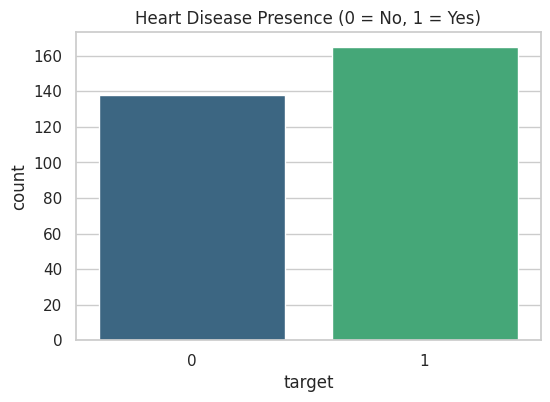

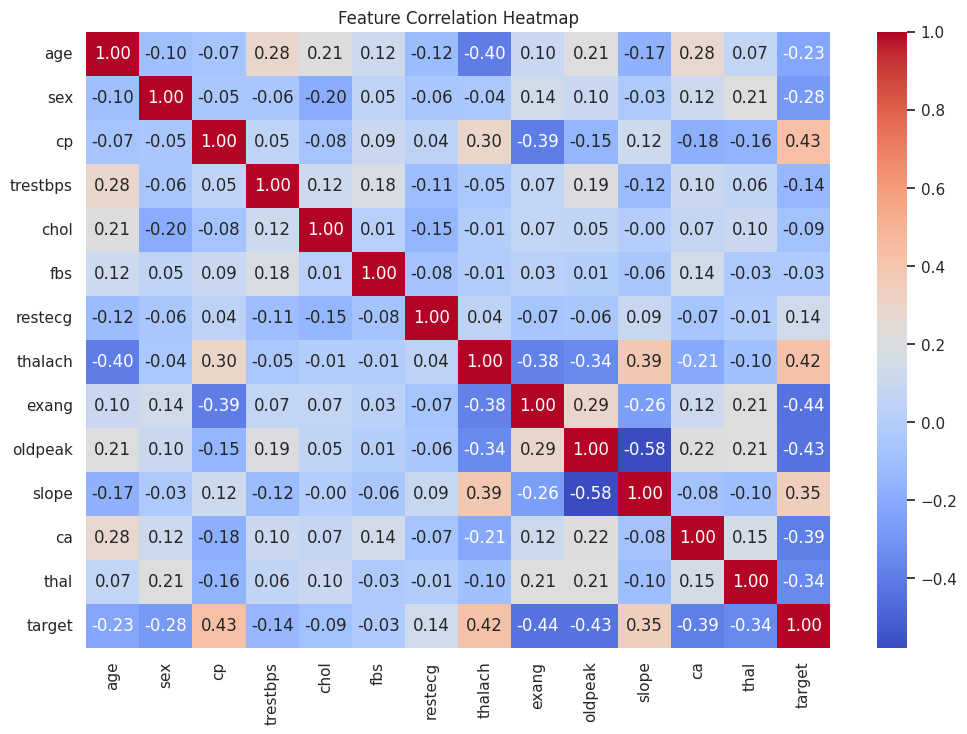

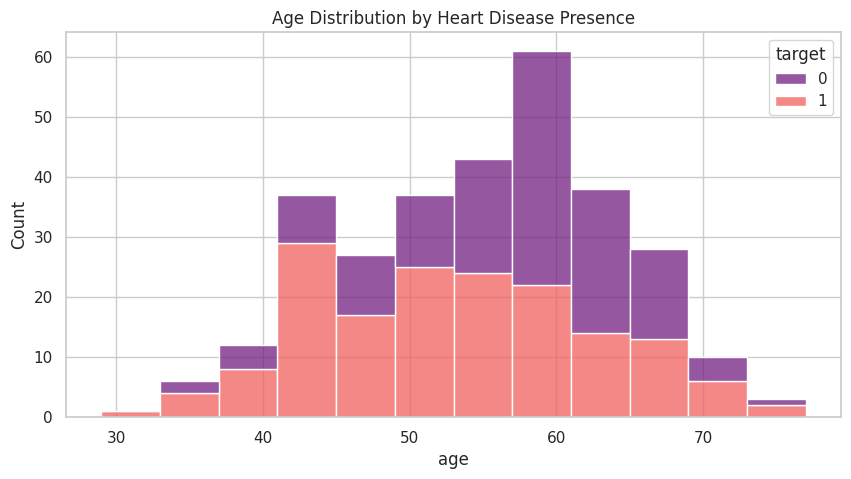

In [ ]:
sns.set_theme(style="whitegrid")

# 1. Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Heart Disease Presence (0 = No, 1 = Yes)')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Age vs Heart Disease
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', multiple='stack', palette='magma')
plt.title('Age Distribution by Heart Disease Presence')
plt.show()

Data Preprocessing

In [ ]:
# Convert categorical variables into dummy variables
categorical_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define Features (X) and Target (y)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Data Preprocessing Complete.")

Data Preprocessing Complete.


Model Training and Evaluation

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.868852   0.857143  0.909091  0.882353  0.899351
1        Decision Tree  0.803279   0.783784  0.878788  0.828571  0.796537
2        Random Forest  0.803279   0.783784  0.878788  0.828571  0.878247
3       Neural Network  0.803279   0.800000  0.848485  0.823529  0.888528


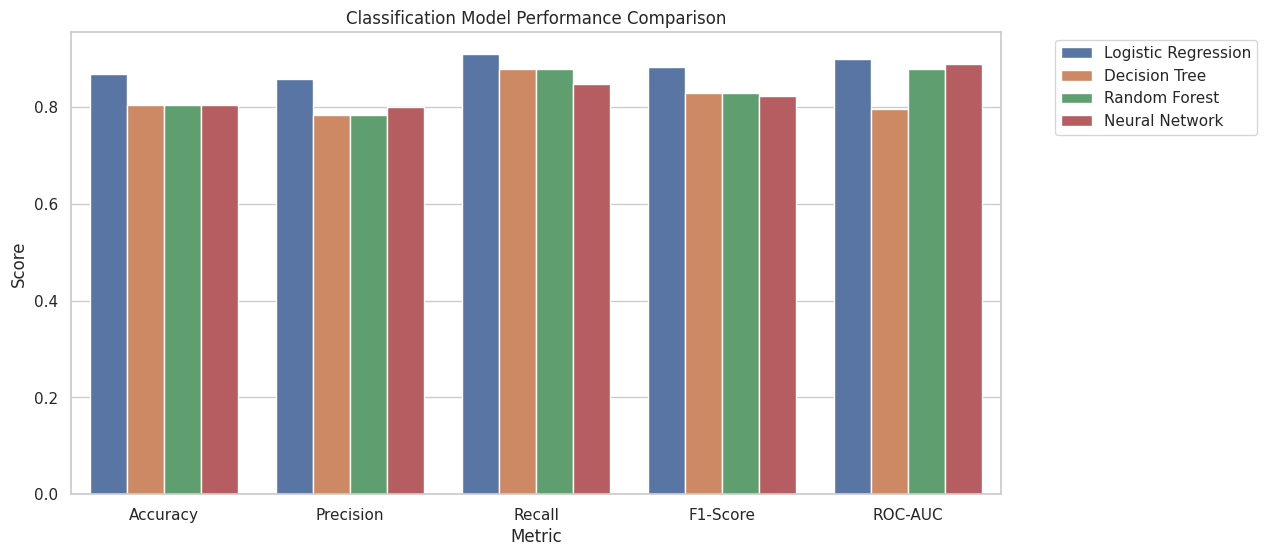

In [ ]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.fit(X_train, y_train).predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Store metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Display Results
results_df = pd.DataFrame(results)
print(results_df)

# Plot Model Comparison
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 6))
sns.barplot(x="Metric", y="Score", hue="Model", data=results_melted)
plt.title("Classification Model Performance Comparison")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Feature Importance (Random Forest)




/tmp/ipython-input-1812885342.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='Blues_r')


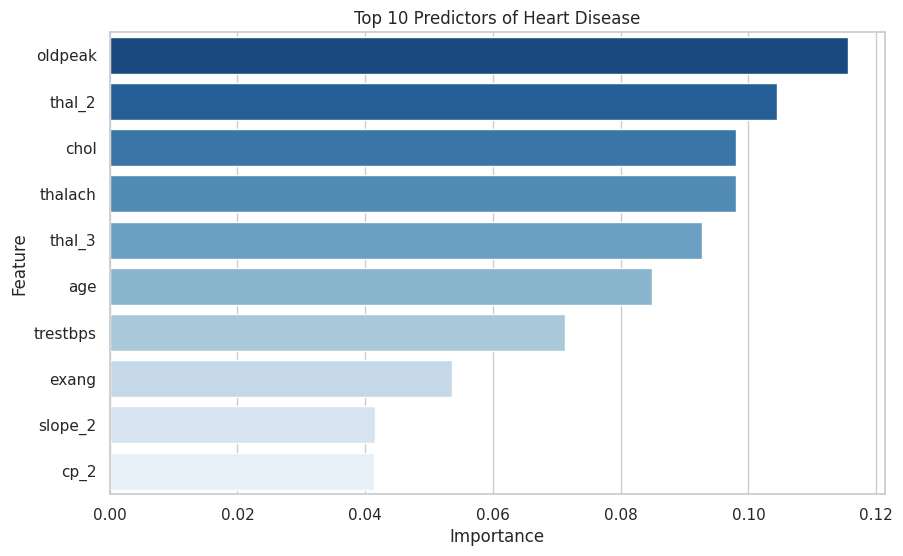

In [ ]:
rf = models["Random Forest"]
importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='Blues_r')
plt.title('Top 10 Predictors of Heart Disease')
plt.show()